In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

In [2]:
OHCO = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
SENTS = OHCO[:4]

# Subset of columns from salex
emo_cols = "anger anticipation disgust fear joy sadness surprise trust sentiment".split()

In [3]:
CORPUS = pd.read_csv("/kaggle/input/notebooks/isabellouisedelgado/text-as-data-final-project-corpus/GothicNovels_CORPUS.csv").set_index(OHCO)
LIB = pd.read_csv("/kaggle/input/notebooks/isabellouisedelgado/text-as-data-final-project-corpus/GothicNovels_LIB.csv").set_index("book_id")
BOW = pd.read_csv("/kaggle/input/notebooks/isabellouisedelgado/text-as-data-final-project-bow-dctm-and-tfidf/GothicNovels_BOW.csv").set_index("book_id")

In [4]:
salex_file = "/kaggle/input/datasets/ontoligent/ds-5001-sentiment-lexicons/lexicons/salex_nrc.csv"

In [5]:
SALEX = pd.read_csv(salex_file).set_index('term_str')
SALEX.columns = [col.replace('nrc_','') for col in SALEX.columns]
SALEX

,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,
abandon,0,0,0,1,0,1,0,1,0,0,-1
abandoned,1,0,0,1,0,1,0,1,0,0,-1
abandonment,1,0,0,1,0,1,0,1,1,0,-1
abduction,0,0,0,1,0,1,0,1,1,0,-1
aberration,0,0,1,0,0,1,0,0,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...
young,0,1,0,0,1,0,1,0,1,0,1
youth,1,1,0,1,1,0,1,0,1,0,1
zeal,0,1,0,0,1,0,1,0,1,1,1


In [6]:
LIB = LIB[['author','title']]
LIB

,author,title
book_id,,
43,"STEVENSON, ROBERT",DR JEKYLL AND MR HYDE
175,"LEROUX, GASTON",THE PHANTOM OF THE OPERA
345,"STOKER, BRAM",DRACULA
696,"WALPOLE, HORACE",CASTLE OF OTRANTO
1952,"GILMAN, CHARLOTTE",THE YELLOW WALLPAPER
3268,"RADCLIFFE, ANN",THE MYSTERIES OF UDOLPHO
5182,"REEVE, CLARA",THE OLD ENGLISH BARON
6087,"POLIDORI, JOHN",THE VAMPYRE
12122,"JACOBS, WW",THE MONKEYS PAW


In [7]:
TOKENS = CORPUS.join(LIB)
TOKENS.head()

token_str  pos pos_group  \
book_id chap_num para_num sent_num token_num                            
696     1        1        0        0           Manfred  NNP        NN   
                                   2            Prince  NNP        NN   
                                   3                of   IN        IN   
                                   4           Otranto  NNP        NN   
                                   6               had  VBD        VB   

                                             term_str        period  \
book_id chap_num para_num sent_num token_num                          
696     1        1        0        0          manfred  early gothic   
                                   2           prince  early gothic   
                                   3               of  early gothic   
                                   4          otranto  early gothic   
                                   6              had  early gothic   

                                                       author  \
book_id chap_num para_num sent_num token_num                    
696     1        1        0        0          WALPOLE, HORACE   
                                   2          WALPOLE, HORACE   
                                   3          WALPOLE, HORACE   
                                   4          WALPOLE, HORACE   
                                   6          WALPOLE, HORACE   

                                                          title  
book_id chap_num para_num sent_num token_num                     
696     1        1        0        0          CASTLE OF OTRANTO  
                                   2          CASTLE OF OTRANTO  
                                   3          CASTLE OF OTRANTO  
                                   4          CASTLE OF OTRANTO  
                                   6          CASTLE OF OTRANTO

## Sentiment VOCAB_SENT

In [8]:
TOKENS_SA = TOKENS.join(SALEX, on='term_str', how='left') #.fillna(0)
TOKENS_SA

token_str  pos pos_group  \
book_id  chap_num para_num sent_num token_num                            
696      1        1        0        0           Manfred  NNP        NN   
                                    2            Prince  NNP        NN   
                                    3                of   IN        IN   
                                    4           Otranto  NNP        NN   
                                    6               had  VBD        VB   
...                                                 ...  ...       ...   
20180856 9        119      4        34         whatever  WDT        WD   
                                    35           walked  VBD        VB   
                                    36            there   RB        RB   
                                    38           walked  VBD        VB   
                                    39            alone   RB        RB   

                                               term_str         period  \
book_id  chap_num para_num sent_num token_num                            
696      1        1        0        0           manfred   early gothic   
                                    2            prince   early gothic   
                                    3                of   early gothic   
                                    4           otranto   early gothic   
                                    6               had   early gothic   
...                                                 ...            ...   
20180856 9        119      4        34         whatever  modern gothic   
                                    35           walked  modern gothic   
                                    36            there  modern gothic   
                                    38           walked  modern gothic   
                                    39            alone  modern gothic   

                                                         author  \
book_id  chap_num para_num sent_num token_num                     
696      1        1        0        0           WALPOLE, HORACE   
                                    2           WALPOLE, HORACE   
                                    3           WALPOLE, HORACE   
                                    4           WALPOLE, HORACE   
                                    6           WALPOLE, HORACE   
...                                                         ...   
20180856 9        119      4        34         JACKSON, SHIRLEY   
                                    35         JACKSON, SHIRLEY   
                                    36         JACKSON, SHIRLEY   
                                    38         JACKSON, SHIRLEY   
                                    39         JACKSON, SHIRLEY   

                                                                    title  \
book_id  chap_num para_num sent_num token_num                               
696      1        1        0        0                   CASTLE OF OTRANTO   
                                    2                   CASTLE OF OTRANTO   
                                    3                   CASTLE OF OTRANTO   
                                    4                   CASTLE OF OTRANTO   
                                    6                   CASTLE OF OTRANTO   
...                                                                   ...   
20180856 9        119      4        34         THE HAUNTING OF HILL HOUSE   
                                    35         THE HAUNTING OF HILL HOUSE   
                                    36         THE HAUNTING OF HILL HOUSE   
                                    38         THE HAUNTING OF HILL HOUSE   
                                    39         THE HAUNTING OF HILL HOUSE   

                                               anger  anticipation  disgust  \
book_id  chap_num para_num sent_num token_num                                 
696      1        1        0        0            NaN           NaN      NaN   
         

## Sentiment BOW_SENT

In [9]:
BOW_SA = BOW.join(SALEX, on='term_str', how='left')
BOW_SA

,chap_num,term_str,n,tfidf,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
book_id,,,,,,,,,,,,,,,
43,8,case,1,2.186938,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,-1.0
43,8,dr,1,2.980351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43,8,full,1,2.086145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43,8,henry,1,3.956629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43,8,jekyll,1,5.223832,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20180856,9,yes,2,0.775931,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20180856,9,you,74,0.801915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20180856,9,young,1,0.843781,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0


In [10]:
BOOK_SA = TOKENS_SA.fillna(0).groupby('book_id')[emo_cols].mean()

In [11]:
DOC_SA = BOW_SA.groupby(['book_id', 'chap_num'])['sentiment'].mean().to_frame()
DOC_SA

sentiment
book_id  chap_num           
43       8          0.000000
         9          0.064220
         10        -0.189394
         11         0.139535
         12        -0.125000
...                      ...
20180856 5         -0.170124
         6         -0.091429
         7         -0.083770
         8         -0.064748
         9         -0.016260

[120 rows x 1 columns]

## Sentiment Plot (4)

In [12]:
def tag_term_str(x):
    if pd.isna(x.sentiment):
        html_str = x.term_str
    else:
        html_str = f"<span class='sent{int(np.sign(x.sentiment))}'>{x.term_str}</span>"
    return html_str

In [13]:
TOKENS_SA['html'] = TOKENS_SA.apply(tag_term_str, axis=1)

In [14]:
SENT_SA = TOKENS_SA.groupby(SENTS)[emo_cols].mean()
SENT_SA['html_str'] = TOKENS_SA.groupby(SENTS)[['html']].apply(lambda x: ' '.join(map(str, x.html)))

In [15]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk import download as nltk_download
nltk_download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [16]:
analyser = SentimentIntensityAnalyzer()

In [17]:
SENT_SA['sent_str'] = TOKENS_SA.groupby(SENTS)[['term_str']].apply(lambda x: ' '.join(map(str, x.term_str)))
SENT_VADER = SENT_SA.sent_str.apply(analyser.polarity_scores).apply(pd.Series)
SENT_VADER.head()

neg    neu    pos  compound
book_id chap_num para_num sent_num                               
43      8        0        0         0.000  1.000  0.000    0.0000
                 1        0         0.000  1.000  0.000    0.0000
        9        0        0         0.180  0.718  0.103   -0.2523
                          1         0.000  0.960  0.040    0.2732
                          2         0.057  0.850  0.093    0.3182

In [18]:
def plot_book_sa(book_id, wf = 5):
    # wf: window size factor
    df = SENT_VADER.loc[book_id]
    w = int(df.shape[0] / wf)
    fig, axes = plt.subplots(3, 1, figsize=(25,15), sharex=True, sharey=False)
    plt.suptitle(book_id, y=1, fontsize=20)
    df[['pos','neg']].rolling(w).mean().plot(ax=axes[0])
    df[['neu']].rolling(w).mean().plot(ax=axes[1])
    df[['compound']].rolling(w).mean().plot(ax=axes[2])
    plt.tight_layout()
    sns.despine(left=True)
    plt.show()

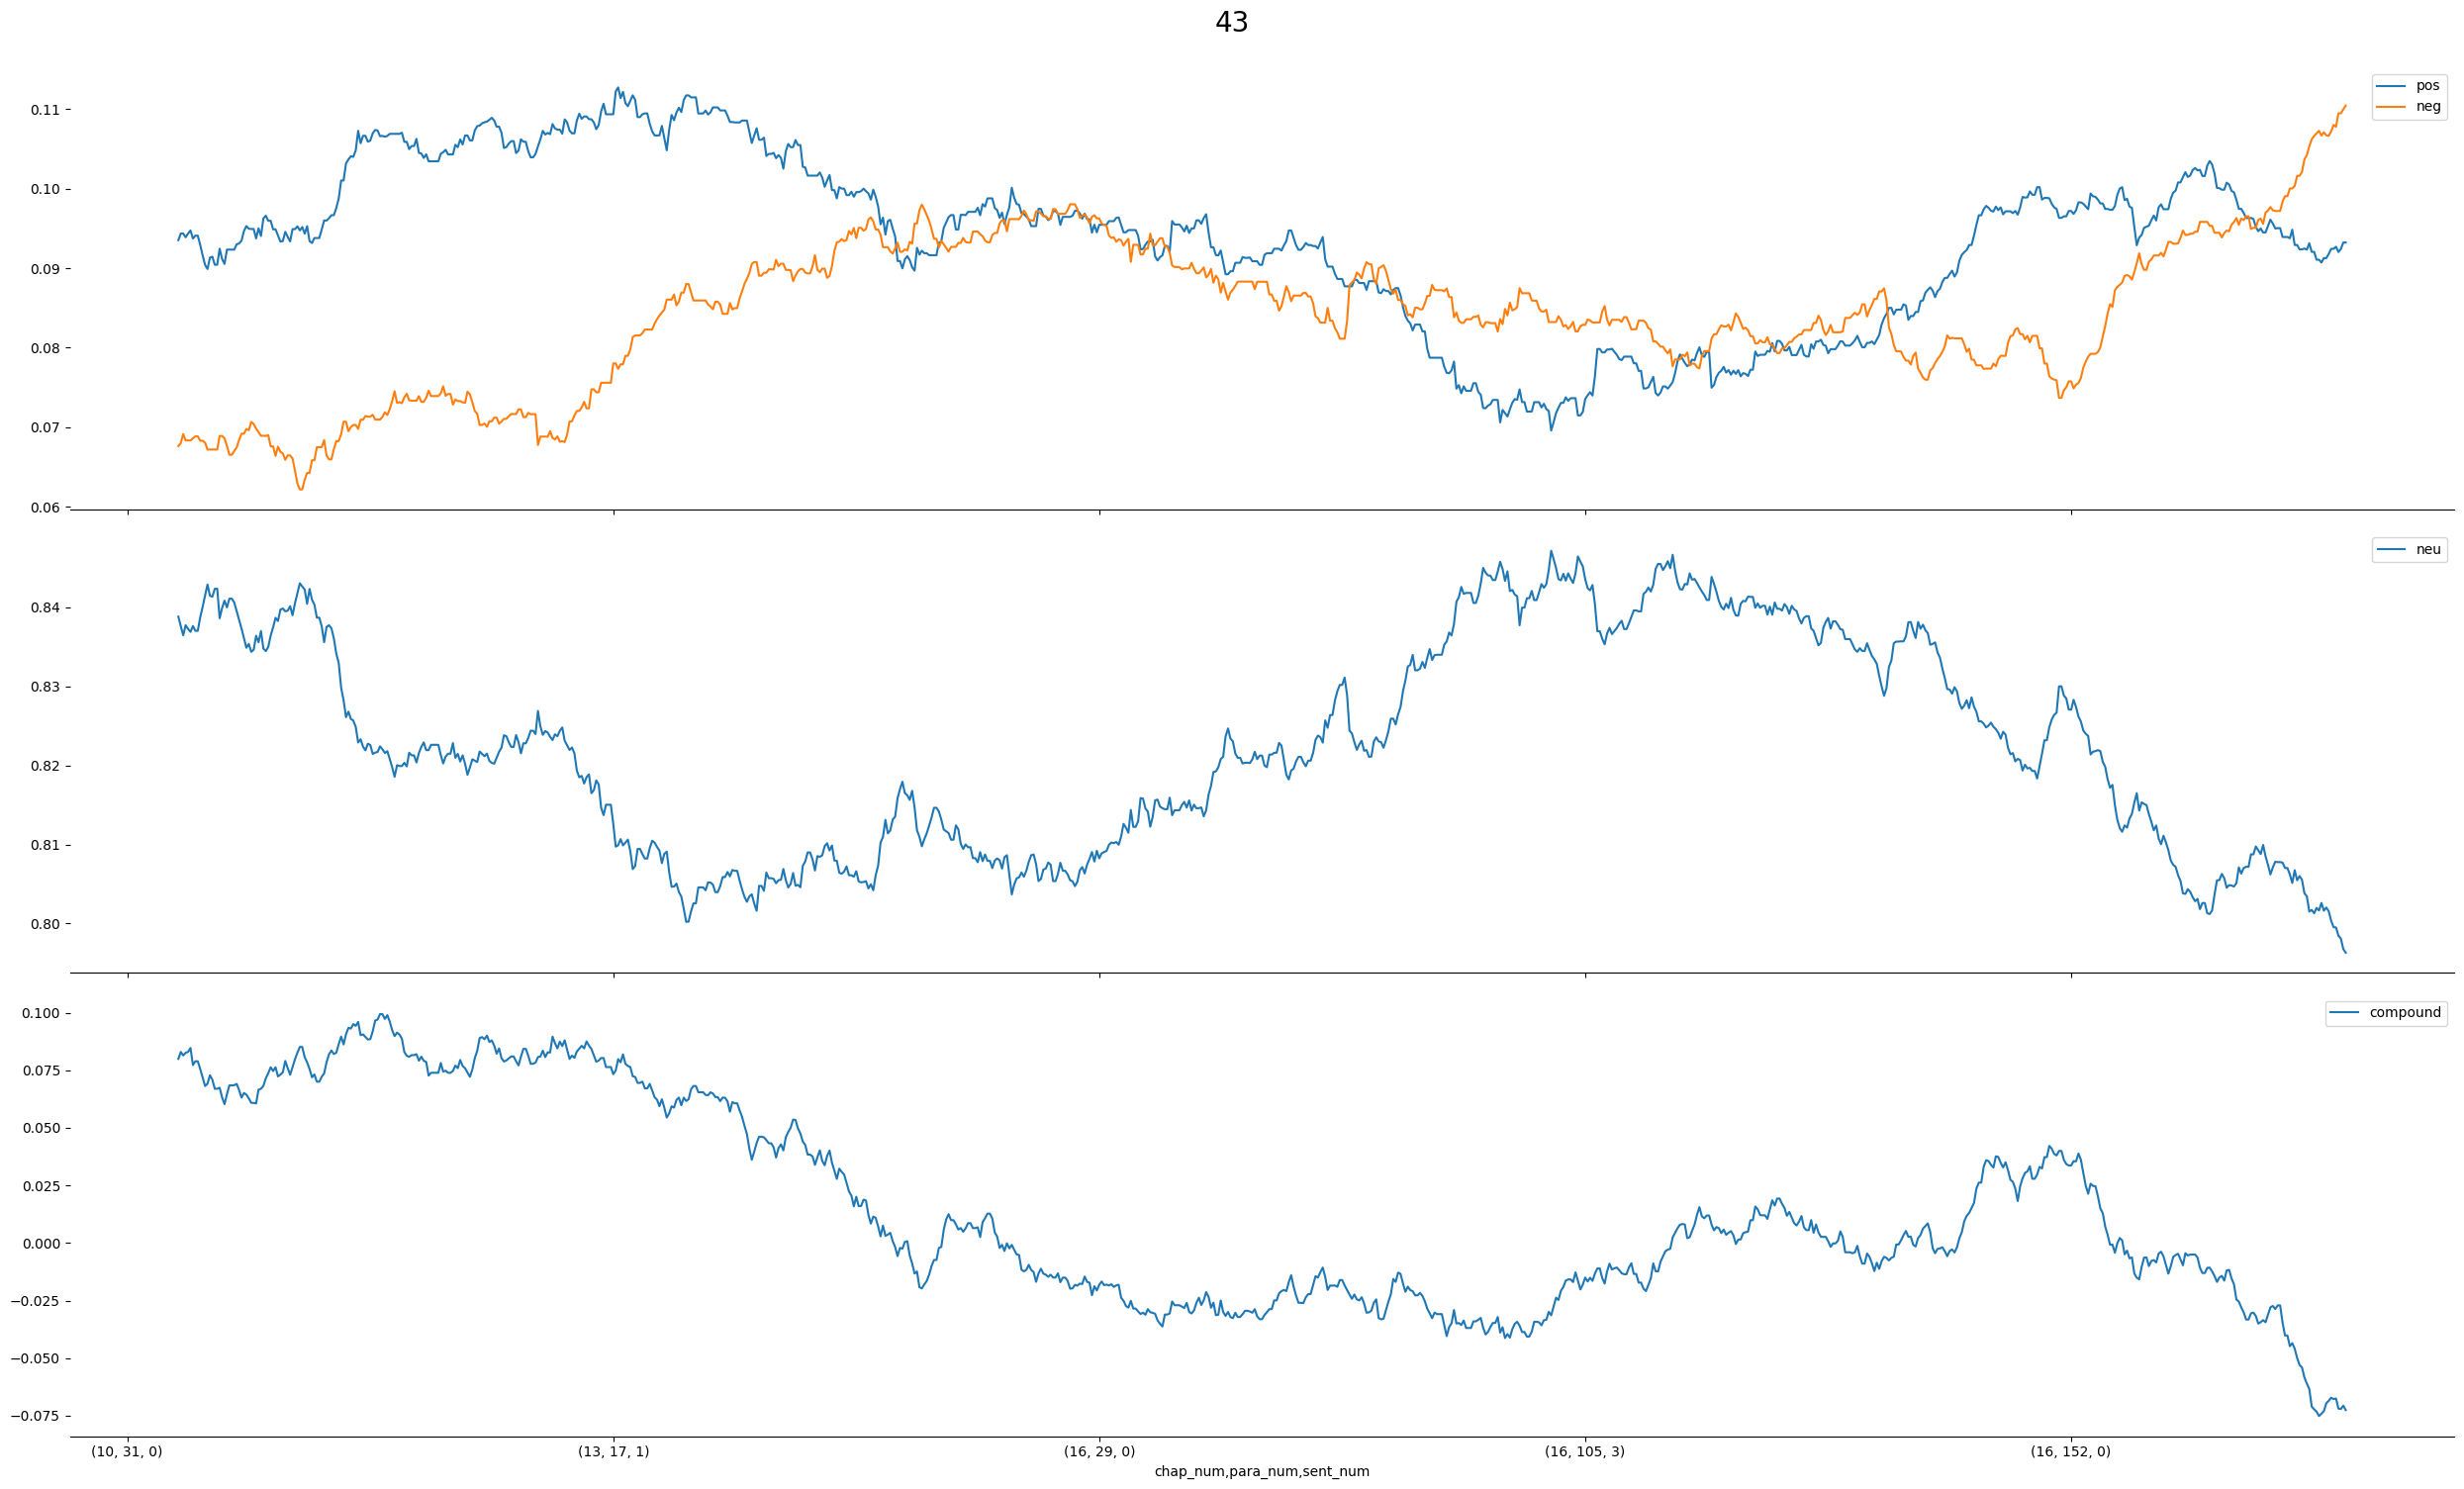

In [19]:
plot_book_sa(43)

# Riff 2

In [20]:
BOOK_SA = TOKENS_SA.fillna(0).groupby('period')[emo_cols].mean()

In [21]:
BOOK_SA

,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,sentiment
period,,,,,,,,,
classical gothic,0.024664,0.021309,0.018496,0.029411,0.025235,0.027919,0.012721,0.027662,-0.006603
early gothic,0.015195,0.019774,0.011118,0.021021,0.022766,0.021563,0.012737,0.028199,0.003427
modern gothic,0.013482,0.015350,0.009356,0.017511,0.018771,0.017543,0.011602,0.022447,0.003167
victorian gothic,0.014421,0.016685,0.011082,0.021387,0.019257,0.016978,0.010166,0.025030,0.002583


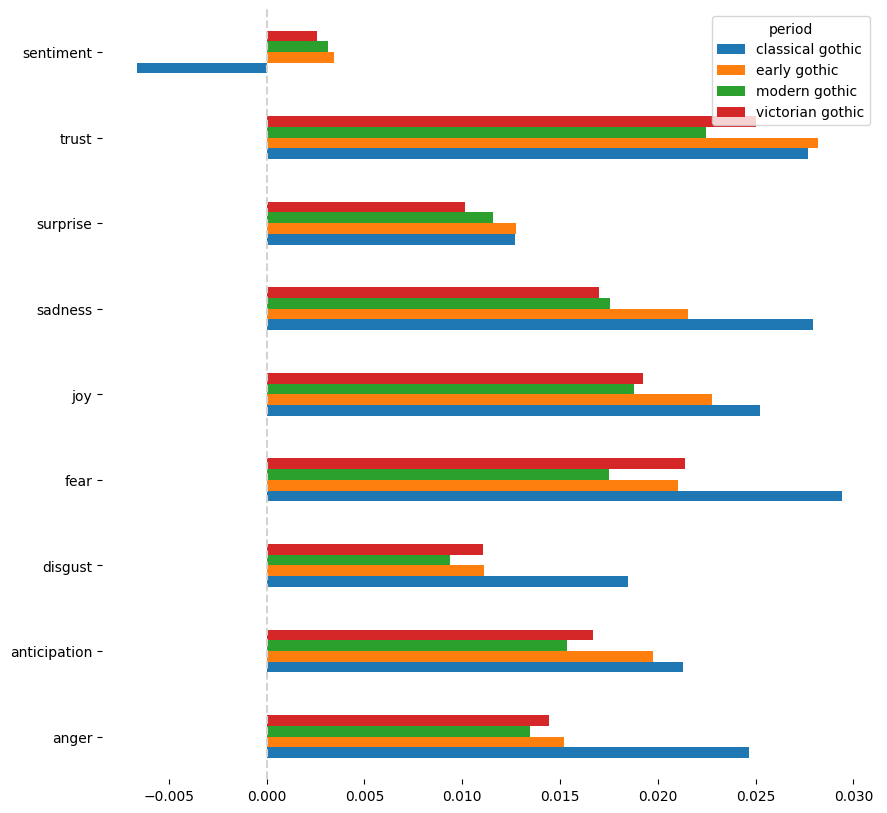

In [22]:
ax = BOOK_SA.loc[['classical gothic','early gothic','modern gothic','victorian gothic']].T.plot.barh(figsize=(10,10))
ax.axvline(0, c='lightgray', ls='--')
sns.despine(left=True, bottom=True)
plt.show()

# Riff 3

In [23]:
from IPython.display import display, HTML

In [24]:
def tag_term_str(x):
    if pd.isna(x.sentiment):
        html_str = x.term_str
    else:
        html_str = f"<span class='sent{int(np.sign(x.sentiment))}'>{x.term_str}</span>"
    return html_str

In [25]:
TOKENS_SA['html'] = TOKENS_SA.apply(tag_term_str, axis=1)

In [26]:
TOKENS_SA.sample(10).html

book_id   chap_num  para_num  sent_num  token_num
20180856  9         26        4         2                                           t
41445     18        38        4         11            <span class='sent1'>lion</span>
43        16        145       4         0                                           i
53685     3         66        1         17                                         to
3268      3         539       6         14                                         we
          4         747       3         21           <span class='sent1'>count</span>
175       4         79        0         3                                          no
3268      1         279       1         17                                   returned
          2         123       1         25                                 frequently
                    133       3         15                                        did
Name: html, dtype: object

In [27]:
SENT_SA = TOKENS_SA.groupby(SENTS)[emo_cols].mean()
SENT_SA['html_str'] = TOKENS_SA.groupby(SENTS)[['html']].apply(lambda x: ' '.join(map(str, x.html)))

In [28]:
SENT_SA.sample(10).html_str.tolist()

["i have mentioned it only to <span class='sent1'>explain</span> why on arriving with the vicomte de chagny in the cellars of the <span class='sent1'>opera</span> i was bound to protect my <span class='sent1'>companion</span> against the everthreatening <span class='sent-1'>danger</span> of <span class='sent-1'>death</span> by strangling",
 'i am old',
 "madam said theresa he looks so thin to what he used to do and so <span class='sent-1'>melancholy</span> and then he wears his arm in a sling",
 "i <span class='sent-1'>hate</span> this wandering around in the dark",
 "even mrs harker seems to <span class='sent-1'>lose</span> sight of her trouble for whole spells it is only now and again when something recalls it to her mind that she thinks of her <span class='sent-1'>terrible</span> <span class='sent-1'>scar</span>",
 "yet <span class='sent-1'>afraid</span> of giving a loose to <span class='sent1'>hope</span> and suspecting from what had passed the inflexibility of manfred s temper he 

In [29]:
# This function will print sentences using color coding for sentiment values
def sample_sentences(df, n=10):
    
    rows = []
    for idx in df.sample(n).index:

        # Map background color to sentiment valences
        valence = round(df.loc[idx, 'sentiment'], 4)     
        if valence > 0: color = '#ccffcc'
        elif valence < 0: color = '#ffcccc'
        else: color = '#f2f2f2'

        # Create a table row
        rows.append(f"""
        <tr style="background-color:{color};padding:.5rem 1rem;font-size:110%;">
            <td>{idx}</td>
            <td width="400" style="text-align:left;">{df.loc[idx, 'html_str']}</td>
            <td>{valence}</td>
        </tr>
        """)

    # Define CSS style element to apply color to fonts by class
    display(HTML("""
    <style>
    #sample1 td{
        font-size:120%;
        vertical-align:top;
    } 
    .sent-1{
        color:red;
        font-weight:bold;
    } 
    .sent1{
        color:green;
        font-weight:bold;
    }
    </style>
    """))
    
    # Create the table
    display(HTML(f"""
    <table id="sample1">
        <tr>
            <th>ID</th>
            <th>Sentence</th>
            <th width="600">Valence</th>
        </tr>
        {"".join(rows)}
    </table>
    """))

In [30]:
sample_sentences(SENT_SA, 20)

ID,Sentence,Valence
"(1952, 1, 136, 2)",i am a doctor dear and i know,1.0
"(3268, 3, 452, 0)",but they talked of a seanymph said emily how came these good people to think of a seanymph,1.0
"(20180856, 5, 36, 3)",or with each other,nan
"(41445, 27, 36, 2)",this sentiment of the worth of my nature supported me when others would have been oppressed for i deemed it criminal to throw away in useless grief those talents that might be useful to my fellowcreatures,-1.0
"(3268, 1, 507, 2)",on the distant horizon to the south she discovered the wild summits of the pyrenees and her fancy immediately painted the green pastures of gascony at their feet,0.4
"(53685, 1, 26, 0)",but while he was applauding himself for this resolution the door opened and the figure appeared at it beckoning and nodding to him with a familiarity somewhat terrifying,1.0
"(175, 20, 132, 0)",oh,nan
"(3268, 2, 379, 0)",annette blushed and emily smiled and they passed on to the extremity of this suite of apartments and found themselves after some further perplexity once more at the top of the marble staircase where annette left emily while she went to call one of the servants of the castle to show them to the chamber for which they had been seeking,0.3333
"(345, 24, 16, 17)",this must not be,nan
"(20180856, 3, 139, 2)",gossip says she hanged herself from the turret on the tower but when you have a house like hill house with a tower and a turret gossip would hardly allow you to hang yourself anywhere else,nan
